In [13]:
import os
import copy
import relbench
import numpy as np
from tqdm import tqdm

import torch
import torch_geometric
import torch_frame

from torch_geometric.seed import seed_everything
import matplotlib.pyplot as plt

import json
import pandas as pd

seed_everything(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
database_name = 'rel-f1'
task_name = 'driver-dnf'
model_dir = f"/home/rissakiagapi/rdl-explain-data/relbench_models/{database_name}/{task_name}/explained_model/"
data_dir = f"/home/rissakiagapi/rdl-explain-data/relbench_models/{database_name}/"

### Load Database + Task

In [15]:
from relbench.datasets import get_dataset
from relbench.tasks import get_task

dataset = get_dataset(database_name, download=False)
task = get_task(database_name, task_name, download=False)

### Load Hetero-Graph Data 

In [16]:
data = torch.load(os.path.join(data_dir, "data.pt"), weights_only=False)
col_stats_dict = torch.load(os.path.join(data_dir, "col_stats_dict.pt"), weights_only=False)

### Load model-to-explain

In [17]:
from rdl_explain.model import Model
from rdl_explain.model import ModelConfig

gnn_params_dict = json.load(open(os.path.join(model_dir, "gnn_params.json"), 'r'))
model_config = ModelConfig(**gnn_params_dict)

model_to_explain = Model(
    data=data,
    col_stats_dict=col_stats_dict,
    num_layers=model_config.gnn_layers,
    channels=model_config.channels,
    out_channels=model_config.out_channels,
    aggr=model_config.aggr,
    norm=model_config.norm,
).to(device)

# Load trained model
model_state_dict = torch.load(os.path.join(model_dir, "model_state_dict.pth"), weights_only=False)
model_to_explain.load_state_dict(model_state_dict)

<All keys matched successfully>

### Run inference to generate predictions

In [18]:
from relbench.modeling.graph import get_node_train_table_input
from torch_geometric.loader import NeighborLoader

@torch.no_grad()
def run_inference(model, data, task, split, device, batch_size=64):
    """Run GNN inference for a split and return ordered logits."""
    model.eval()
    table = task.get_table(split)
    table_input = get_node_train_table_input(table=table, task=task)

    # Normalise entity table name to match data.node_types casing (data.pt may
    # capitalise node types differently from relbench task, e.g. "Study" vs "study")
    entity_table = task.entity_table
    for nt in data.node_types:
        if nt.lower() == entity_table.lower():
            entity_table = nt
            break
    _, node_ids = table_input.nodes

    # transform=None: relbench's transform assigns labels via batch[entity_table].input_id
    # using the original (possibly mismatched) casing; inference doesn't need labels.
    loader = NeighborLoader(
        data,
        num_neighbors=[-1] * model_config.gnn_layers,
        time_attr="time" if table_input.time is not None else None,
        input_nodes=(entity_table, node_ids),
        input_time=table_input.time,
        transform=None,
        batch_size=batch_size,
        shuffle=False,
    )
    pred_list = []
    for batch in tqdm(loader, desc=f"Inference [{split}]"):
        batch = batch.to(device)
        out = model(batch, entity_table)
        out = out.view(-1) if out.size(-1) == 1 else out
        pred_list.append(out.cpu())
    return torch.cat(pred_list, dim=0).numpy()

split_predictions = {}
for split in ["train", "val", "test"]:
    logits = run_inference(model_to_explain, data, task, split, device)
    probs = 1 / (1 + np.exp(-logits))  # sigmoid
    hard = (probs >= 0.5).astype(float)
    split_predictions[split] = {
        "output": logits,
        "processed_output": probs,
        "predictions": hard,
    }
    print(f"{split}: {len(logits)} predictions, positive rate = {hard.mean():.3f}")

Inference [train]: 100%|██████████| 179/179 [01:58<00:00,  1.51it/s]


train: 11411 predictions, positive rate = 0.974


Inference [val]: 100%|██████████| 9/9 [00:09<00:00,  1.10s/it]


val: 566 predictions, positive rate = 0.919


Inference [test]: 100%|██████████| 11/11 [00:13<00:00,  1.25s/it]

test: 702 predictions, positive rate = 0.915


### Make the Explainer Config

In [19]:
from rdl_explain.explain.config import ExplainerConfig
explainer_config = ExplainerConfig(device=device, gnn_layers=model_config.gnn_layers, inference_batch_size=16)

In [20]:
def make_explanation_task(
    prediction_task: relbench.tasks.BaseTask,
    data: torch_geometric.data.HeteroData,
    split_predictions: dict,
    explanation_target_type: str = 'soft',
):
    explanation_task = copy.deepcopy(prediction_task)

    for split in ["train", "val", "test"]:
        table = explanation_task.get_table(split)
        preds = split_predictions[split]
        table.df["output"] = preds["output"]
        table.df["processed_output"] = preds["processed_output"]
        table.df["predictions"] = preds["predictions"]
        setattr(explanation_task, f"{split}_table", table)

    # make sure all necessary columns are present
    assert all(col in table.df.columns for col in ['predictions', 'processed_output'] for table in [explanation_task.train_table, explanation_task.val_table, explanation_task.test_table])

    # Set the explanation target columns
    explanation_task.explanation_target_column = 'predictions'
    explanation_task.explanation_soft_target_column = 'processed_output'
    explanation_task.target_col = explanation_task.explanation_soft_target_column if explanation_target_type == 'soft' else explanation_task.explanation_target_column
    explanation_task.explanation_target_type = explanation_target_type

    # find the name of the entity table as it appears in the data (in the data it might use different capitalization)
    entity_table_name = explanation_task.entity_table.lower()
    for key in data.node_types:
        if key.lower() == entity_table_name:
            explanation_task.entity_table = key

    return explanation_task

explanation_task = make_explanation_task(
    prediction_task=task,
    data=data,
    split_predictions=split_predictions,
    explanation_target_type='soft',
)

display(explanation_task.train_table.df.head(), len(explanation_task.train_table.df))
print(explanation_task.train_table.df[explanation_task.explanation_target_column].value_counts())
print('entity table: ', explanation_task.entity_table)

,date,driverId,did_not_finish,output,processed_output,predictions
0,2004-08-04,20,1,2.518634,0.925438,1.0
1,2004-08-04,12,1,3.826275,0.978674,1.0
2,2004-07-05,10,0,1.798777,0.858000,1.0
3,2004-07-05,47,0,-0.378558,0.406475,0.0
4,2004-06-05,31,1,4.467306,0.988652,1.0


11411

predictions
1.0    11118
0.0      293
Name: count, dtype: int64
entity table:  Drivers


### Initialize the Explainer

In [21]:
from rdl_explain.explain.explainer import RDLExplainer
explainer = RDLExplainer(explainer_config, model_to_explain, data, explanation_task)

### Learn Column Masks

In [ ]:
# Learn masks
mask_type = 'column'
print(f'Learning mask of type: {mask_type}')
eps = 'auto'
mask_learning_config = {'reg_eps': eps, 'learning_rate': 0.05, 'epochs': 250}
mask_learning_config['explanation_type'] = 'column'
mask_learning_config['elimination_strategy'] = 'permutation_joint'
global_mask, global_mask_vals, global_metrics = explainer.learn_masks(
                                                    eps = mask_learning_config['reg_eps'],
                                                    explanation_type = mask_learning_config['explanation_type'],
                                                    elimination_strategy = mask_learning_config['elimination_strategy'],
                                                    n_epochs = 50, #mask_learning_config['epochs'],
                                                    lr = mask_learning_config['learning_rate'],
                                                )

Learning mask of type: column
[Auto-eps] task_loss_0=0.3160, reg_loss_0=45.00 → eps=0.007024 → rounded=0.005
Epoch 0/50: Loss 0.37176299806688334 - Task Loss 0.3052328339136088 - Regularization 13.306033118664775 - Time-per-epoch 129.58s
Epoch 5/50: Loss 0.3409005451555976 - Task Loss 0.30789208550636776 - Regularization 6.601692071502982 - Time-per-epoch 137.03s
Epoch 10/50: Loss 0.3414773744273933 - Task Loss 0.30750945582406075 - Regularization 6.793583872859207 - Time-per-epoch 102.6s
Epoch 15/50: Loss 0.34042082478014657 - Task Loss 0.307807075189518 - Regularization 6.522750063747332 - Time-per-epoch 189.83s
Epoch 20/50: Loss 0.33999278357391766 - Task Loss 0.3081890016842884 - Regularization 6.360756531092676 - Time-per-epoch 180.38s
Epoch 25/50: Loss 0.3397864132508706 - Task Loss 0.3068883586998721 - Regularization 6.579611061770809 - Time-per-epoch 173.72s
Epoch 30/50: Loss 0.34000317361105115 - Task Loss 0.3071869733786921 - Regularization 6.56324018599243 - Time-per-epoch 1

Number of explanation elements with importance score above 0.1: 26


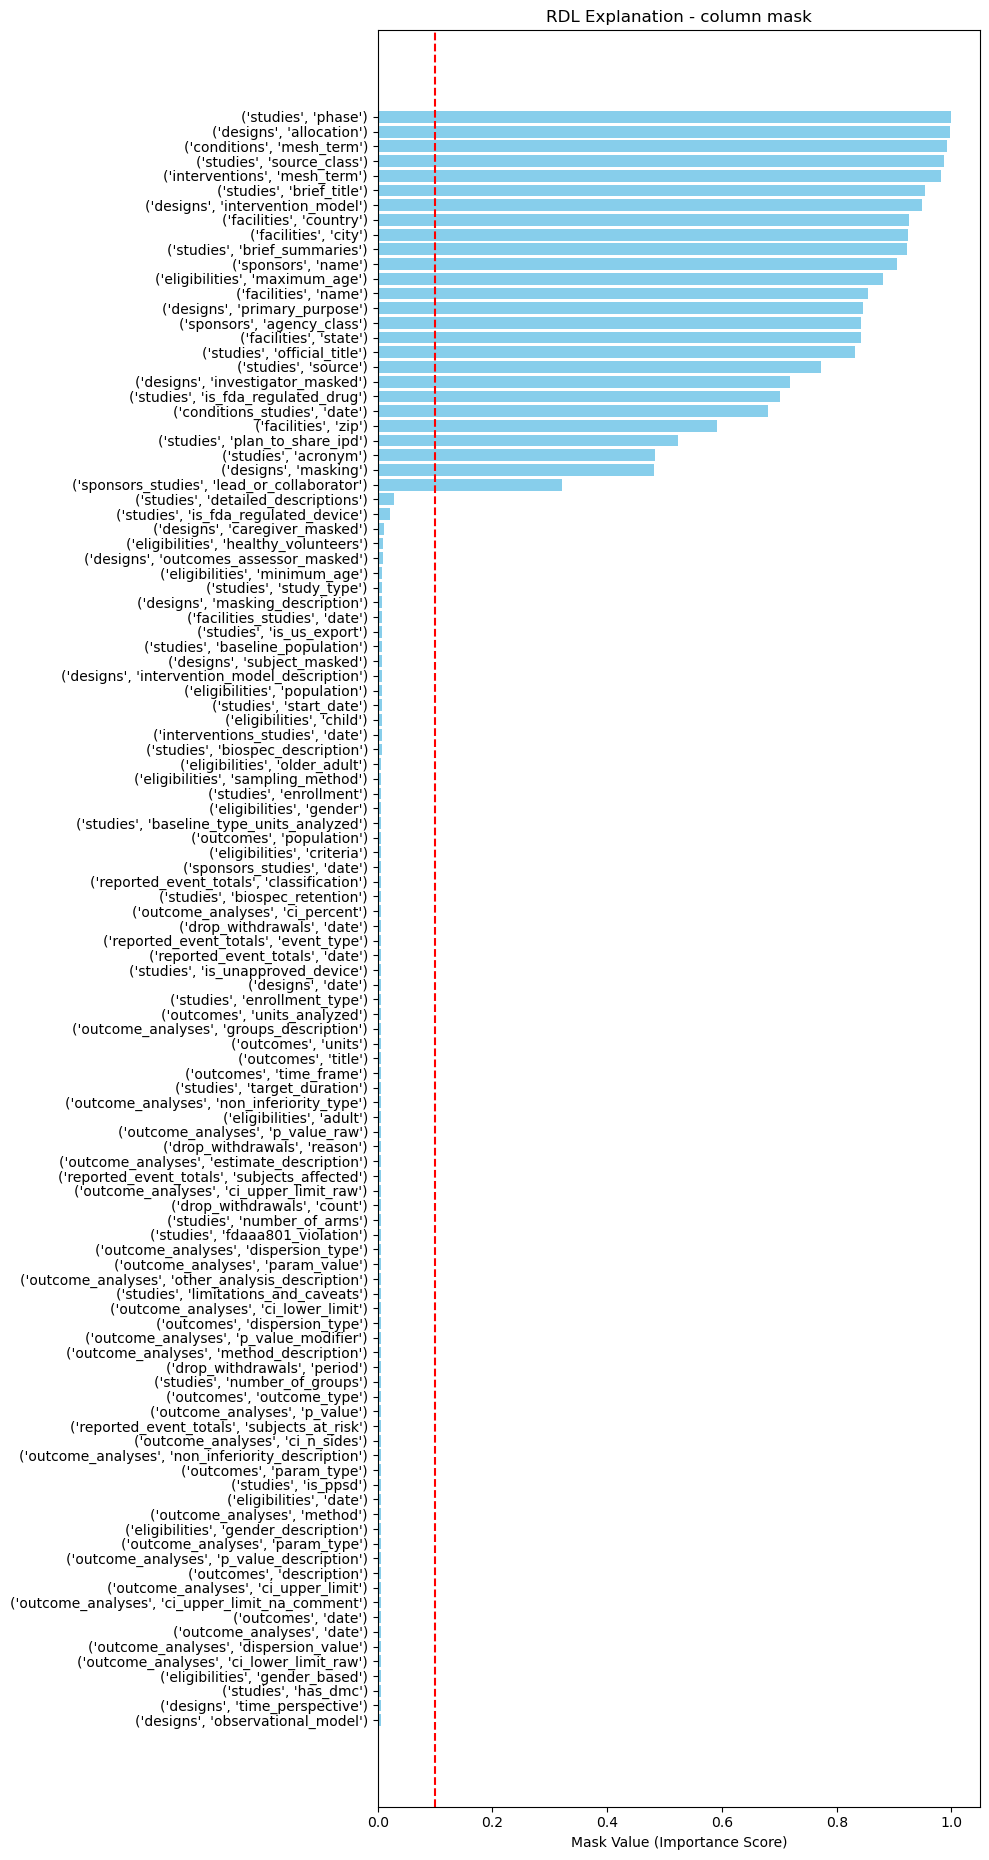

In [ ]:
# Prepare data for plotting
explanation_elements = []
importance_scores = []
for explanation_element, mask_value in global_mask.items():
    explanation_elements.append(f'{explanation_element}')
    importance_scores.append(torch.sigmoid(mask_value).item())  # Apply sigmoid to get importance score between 0 and 1

# Create a DataFrame for easier plotting
importance_df = pd.DataFrame({
    'Explanation Element': explanation_elements,
    'Importance Score': importance_scores
})
# Sort the DataFrame by importance score
importance_df = importance_df.sort_values(by='Importance Score', ascending=False)
threshold = 0.1

# Plotting
plt.figure(figsize=(10, 0.17*len(importance_df)))
plt.barh(importance_df['Explanation Element'], importance_df['Importance Score'], color='skyblue')
plt.xlabel('Mask Value (Importance Score)')
plt.title(f'RDL Explanation - {mask_type} mask')
plt.gca().invert_yaxis()  # Invert y-axis to have the highest scores on top
plt.axvline(x=threshold, color='red', linestyle='--', label=f'Threshold ({threshold})')
plt.tight_layout()

# Number of explanation elements above the threshold
num_important_elements = (importance_df['Importance Score'] > threshold).sum()
print(f'Number of explanation elements with importance score above {threshold}: {num_important_elements}')

# save figure, use reg_eps and k in the filename
os.makedirs(f'./figures/{database_name}_{task_name}', exist_ok=True)
plt.savefig(f'./figures/{database_name}_{task_name}/rdl_explanation_{database_name}_{task_name}_{mask_type}_mask_eps_{mask_learning_config["reg_eps"]}.png')